In [1]:
# Required Libraries
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings('ignore')

## 1. Data Loading ----------

In [2]:
df_train = pd.read_csv("data/train.csv")
df_test = pd.read_csv("data/test.csv")

## 2. Data Preprocessing --------

### 2.1. Data Exploration

In [3]:
df_train.head()

,employee_id,department,region,education,gender,recruitment_channel,no_of_trainings,age,previous_year_rating,length_of_service,awards_won?,avg_training_score,is_promoted
0,65438,Sales & Marketing,region_7,Master's & above,f,sourcing,1,35,5.0,8,0,49,0
1,65141,Operations,region_22,Bachelor's,m,other,1,30,5.0,4,0,60,0
2,7513,Sales & Marketing,region_19,Bachelor's,m,sourcing,1,34,3.0,7,0,50,0
3,2542,Sales & Marketing,region_23,Bachelor's,m,other,2,39,1.0,10,0,50,0
4,48945,Technology,region_26,Bachelor's,m,other,1,45,3.0,2,0,73,0


In [4]:
df_test.head()

,employee_id,department,region,education,gender,recruitment_channel,no_of_trainings,age,previous_year_rating,length_of_service,awards_won?,avg_training_score
0,8724,Technology,region_26,Bachelor's,m,sourcing,1,24,NaN,1,0,77
1,74430,HR,region_4,Bachelor's,f,other,1,31,3.0,5,0,51
2,72255,Sales & Marketing,region_13,Bachelor's,m,other,1,31,1.0,4,0,47
3,38562,Procurement,region_2,Bachelor's,f,other,3,31,2.0,9,0,65
4,64486,Finance,region_29,Bachelor's,m,sourcing,1,30,4.0,7,0,61


In [5]:
df_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 54808 entries, 0 to 54807
Data columns (total 13 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   employee_id           54808 non-null  int64  
 1   department            54808 non-null  object 
 2   region                54808 non-null  object 
 3   education             52399 non-null  object 
 4   gender                54808 non-null  object 
 5   recruitment_channel   54808 non-null  object 
 6   no_of_trainings       54808 non-null  int64  
 7   age                   54808 non-null  int64  
 8   previous_year_rating  50684 non-null  float64
 9   length_of_service     54808 non-null  int64  
 10  awards_won?           54808 non-null  int64  
 11  avg_training_score    54808 non-null  int64  
 12  is_promoted           54808 non-null  int64  
dtypes: float64(1), int64(7), object(5)
memory usage: 5.4+ MB


In [6]:
df_test.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 23490 entries, 0 to 23489
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   employee_id           23490 non-null  int64  
 1   department            23490 non-null  object 
 2   region                23490 non-null  object 
 3   education             22456 non-null  object 
 4   gender                23490 non-null  object 
 5   recruitment_channel   23490 non-null  object 
 6   no_of_trainings       23490 non-null  int64  
 7   age                   23490 non-null  int64  
 8   previous_year_rating  21678 non-null  float64
 9   length_of_service     23490 non-null  int64  
 10  awards_won?           23490 non-null  int64  
 11  avg_training_score    23490 non-null  int64  
dtypes: float64(1), int64(6), object(5)
memory usage: 2.2+ MB


In [7]:
df_train.describe()

,employee_id,no_of_trainings,age,previous_year_rating,length_of_service,awards_won?,avg_training_score,is_promoted
count,54808.000000,54808.000000,54808.000000,50684.000000,54808.000000,54808.000000,54808.000000,54808.000000
mean,39195.830627,1.253011,34.803915,3.329256,5.865512,0.023172,63.386750,0.085170
std,22586.581449,0.609264,7.660169,1.259993,4.265094,0.150450,13.371559,0.279137
min,1.000000,1.000000,20.000000,1.000000,1.000000,0.000000,39.000000,0.000000
25%,19669.750000,1.000000,29.000000,3.000000,3.000000,0.000000,51.000000,0.000000
50%,39225.500000,1.000000,33.000000,3.000000,5.000000,0.000000,60.000000,0.000000
75%,58730.500000,1.000000,39.000000,4.000000,7.000000,0.000000,76.000000,0.000000
max,78298.000000,10.000000,60.000000,5.000000,37.000000,1.000000,99.000000,1.000000


In [8]:
df_train['department'].unique()

array(['Sales & Marketing', 'Operations', 'Technology', 'Analytics',
       'R&D', 'Procurement', 'Finance', 'HR', 'Legal'], dtype=object)

In [9]:
df_train['department'].nunique()

9

In [10]:
print(df_train.shape)
print(df_test.shape)

(54808, 13)
(23490, 12)


In [11]:
len(df_train.columns)

13

### 2.2. Handeling null Values

In [12]:
df_train.isnull().sum()

employee_id                0
department                 0
region                     0
education               2409
gender                     0
recruitment_channel        0
no_of_trainings            0
age                        0
previous_year_rating    4124
length_of_service          0
awards_won?                0
avg_training_score         0
is_promoted                0
dtype: int64

In [13]:
df_test.isnull().sum()

employee_id                0
department                 0
region                     0
education               1034
gender                     0
recruitment_channel        0
no_of_trainings            0
age                        0
previous_year_rating    1812
length_of_service          0
awards_won?                0
avg_training_score         0
dtype: int64

In [14]:
df_train.isna().sum().sort_values(ascending=False)


previous_year_rating    4124
education               2409
employee_id                0
department                 0
region                     0
gender                     0
recruitment_channel        0
no_of_trainings            0
age                        0
length_of_service          0
awards_won?                0
avg_training_score         0
is_promoted                0
dtype: int64

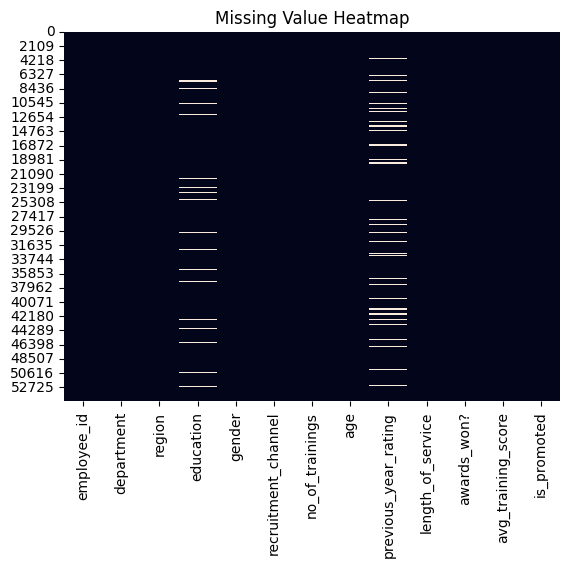

In [15]:
sns.heatmap(df_train.isna(), cbar=False)
plt.title("Missing Value Heatmap")
plt.show()

In [16]:
df_train['education'].value_counts()

education
Bachelor's          36669
Master's & above    14925
Below Secondary       805
Name: count, dtype: int64

In [17]:
df_test['education'].value_counts()

education
Bachelor's          15578
Master's & above     6504
Below Secondary       374
Name: count, dtype: int64

In [18]:
df_train['education'].mode()[0]

"Bachelor's"

In [19]:
print("Train \n",df_train['education'].value_counts(dropna = False , normalize = True)*100)
print("Test \n",df_test['education'].value_counts(dropna = False , normalize = True)*100)

Train 
 education
Bachelor's          66.904467
Master's & above    27.231426
NaN                  4.395344
Below Secondary      1.468764
Name: proportion, dtype: float64
Test 
 education
Bachelor's          66.317582
Master's & above    27.688378
NaN                  4.401873
Below Secondary      1.592167
Name: proportion, dtype: float64


In [20]:
# filling NA with maximum Occurance:

df_train['education'].fillna(df_train['education'].mode()[0], inplace=True)
df_test['education'].fillna(df_test['education'].mode()[0], inplace=True)

In [21]:
print(df_train['previous_year_rating'].value_counts())
print(df_test['previous_year_rating'].value_counts())

previous_year_rating
3.0    18618
5.0    11741
4.0     9877
1.0     6223
2.0     4225
Name: count, dtype: int64
previous_year_rating
3.0    7921
5.0    5097
4.0    4249
1.0    2680
2.0    1731
Name: count, dtype: int64


In [22]:
# replace null values in previous_year_rating by mode
df_train['previous_year_rating'].fillna(df_train['previous_year_rating'].mode()[0], inplace=True)
df_test['previous_year_rating'].fillna(df_test['previous_year_rating'].mode()[0], inplace=True)

### 2.3. Handling Duplicates

In [23]:
df_train.duplicated().sum()

0

In [24]:
df_test.duplicated().sum()

0

In [25]:
# No Duplicate data found

### 2.4. Handling Outliers

In [26]:
df_train.head()

,employee_id,department,region,education,gender,recruitment_channel,no_of_trainings,age,previous_year_rating,length_of_service,awards_won?,avg_training_score,is_promoted
0,65438,Sales & Marketing,region_7,Master's & above,f,sourcing,1,35,5.0,8,0,49,0
1,65141,Operations,region_22,Bachelor's,m,other,1,30,5.0,4,0,60,0
2,7513,Sales & Marketing,region_19,Bachelor's,m,sourcing,1,34,3.0,7,0,50,0
3,2542,Sales & Marketing,region_23,Bachelor's,m,other,2,39,1.0,10,0,50,0
4,48945,Technology,region_26,Bachelor's,m,other,1,45,3.0,2,0,73,0


In [27]:
df_train.columns

Index(['employee_id', 'department', 'region', 'education', 'gender',
       'recruitment_channel', 'no_of_trainings', 'age', 'previous_year_rating',
       'length_of_service', 'awards_won?', 'avg_training_score',
       'is_promoted'],
      dtype='object')

In [28]:
df_test.columns

Index(['employee_id', 'department', 'region', 'education', 'gender',
       'recruitment_channel', 'no_of_trainings', 'age', 'previous_year_rating',
       'length_of_service', 'awards_won?', 'avg_training_score'],
      dtype='object')

In [29]:
dist_cols = ['no_of_trainings', 'age', 'length_of_service', 'avg_training_score']

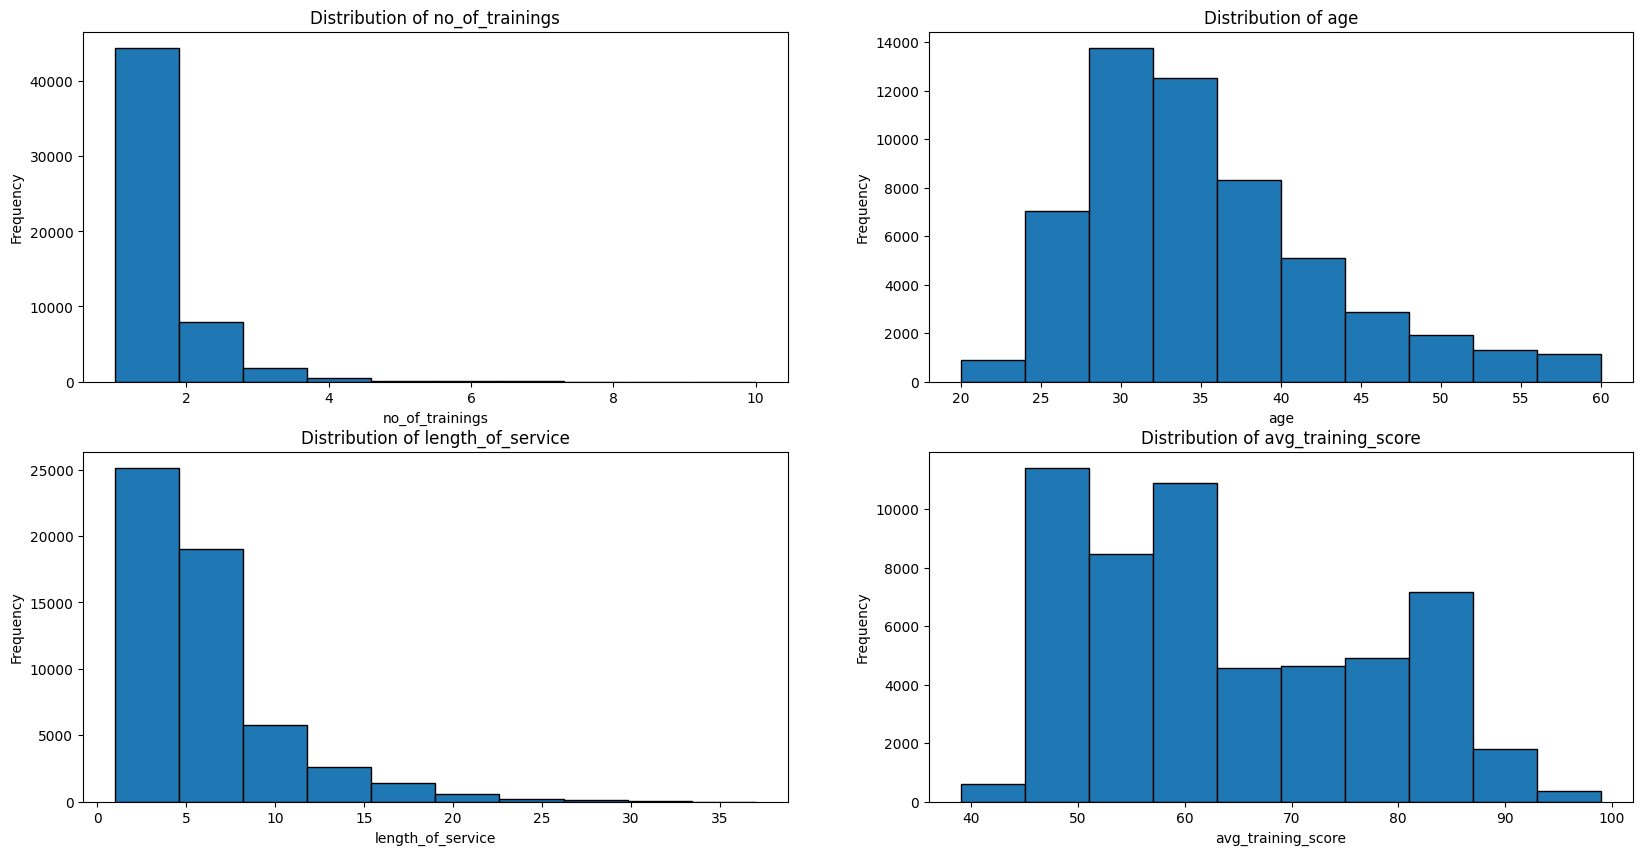

In [30]:
# histogram for outliers in df_train
i = 1
plt.figure(figsize=(20, 10))
for col in dist_cols:
    plt.subplot(2, 2, i)
    plt.hist(df_train[col], bins=10, edgecolor='black')
    plt.title(f'Distribution of {col}')
    plt.xlabel(col)
    plt.ylabel('Frequency')
    i += 1
plt.show()

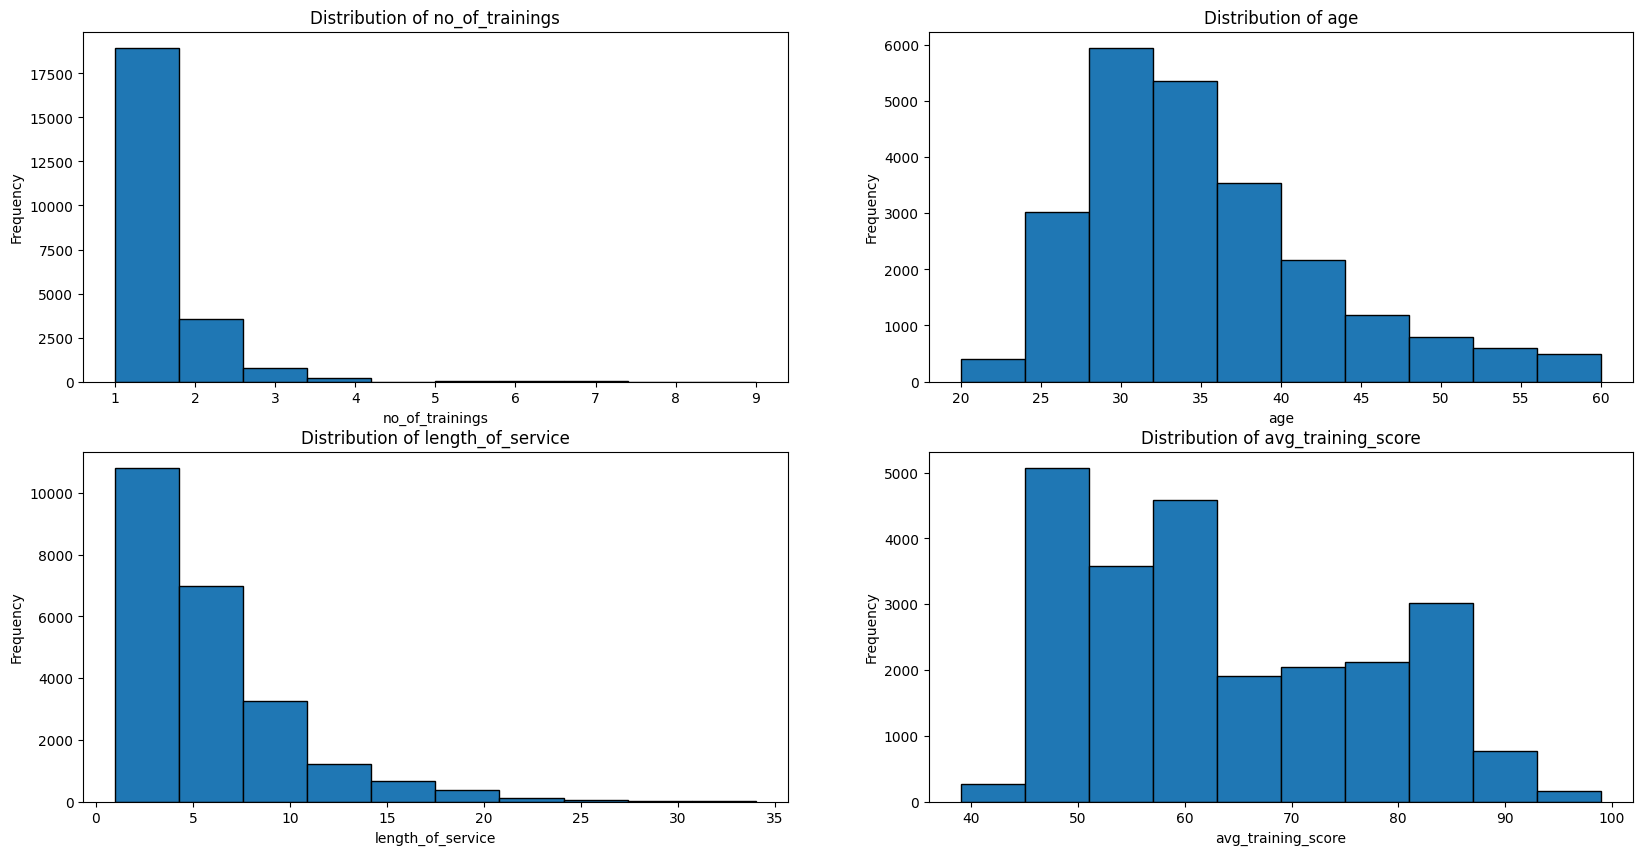

In [31]:
# histogram plot for outliers in df_test
i = 1
plt.figure(figsize=(20, 10))
for col in dist_cols:
    plt.subplot(2, 2, i)
    plt.hist(df_test[col], bins=10, edgecolor='black')
    plt.title(f'Distribution of {col}')
    plt.xlabel(col)
    plt.ylabel('Frequency')
    i += 1
plt.show()

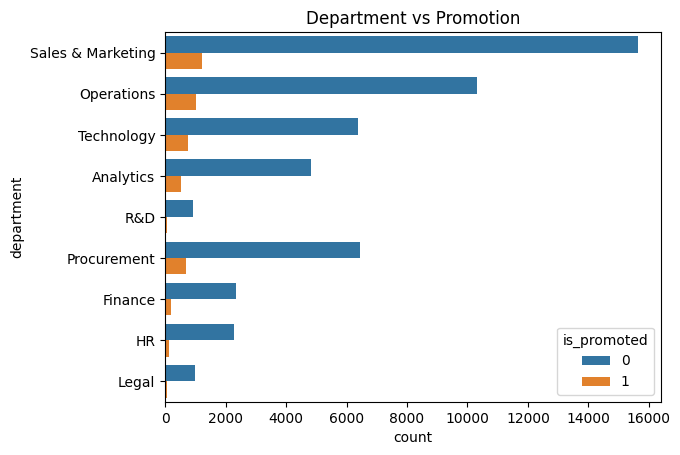

In [32]:
sns.countplot(y="department", hue="is_promoted", data=df_train)
plt.title("Department vs Promotion")
plt.show()

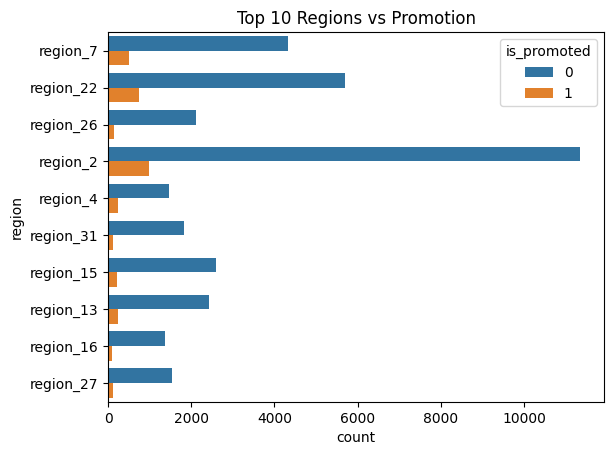

In [33]:
top_regions = df_train["region"].value_counts().head(10).index

sns.countplot(
    y="region",
    hue="is_promoted",
    data=df_train[df_train["region"].isin(top_regions)]
)
plt.title("Top 10 Regions vs Promotion")
plt.show()


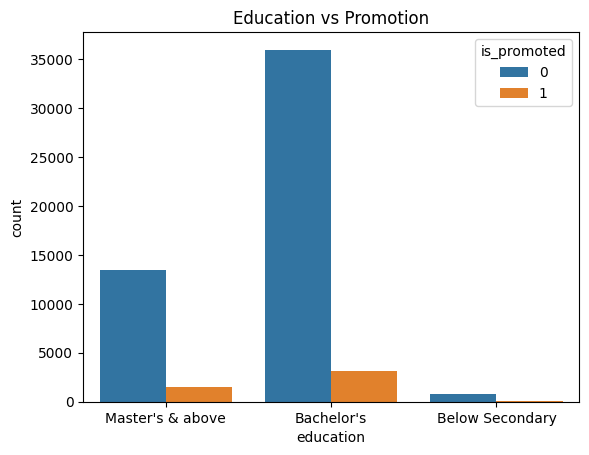

In [34]:
sns.countplot(x="education", hue="is_promoted", data=df_train)
plt.title("Education vs Promotion")
plt.show()

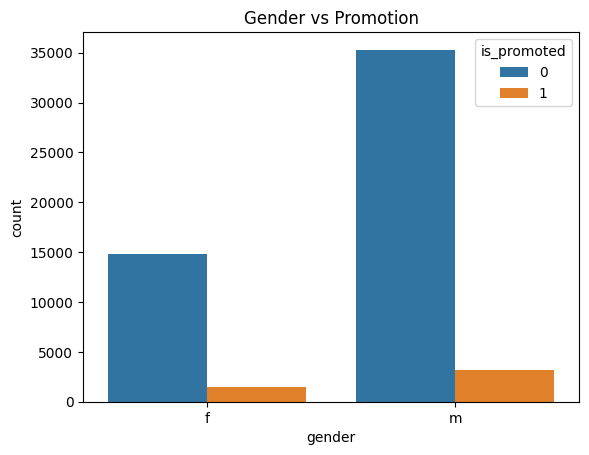

In [35]:
sns.countplot(x="gender", hue="is_promoted", data=df_train)
plt.title("Gender vs Promotion")
plt.show()

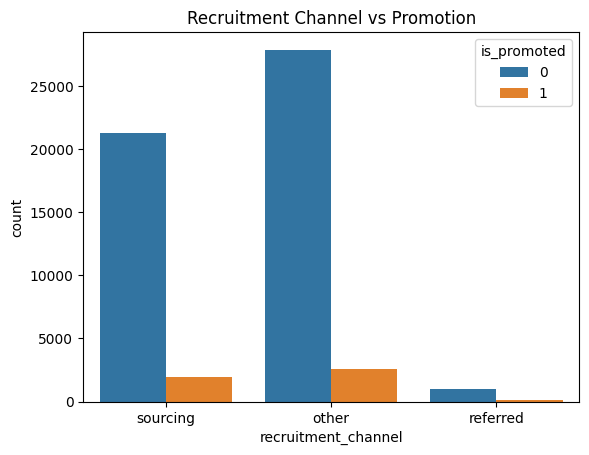

In [36]:
sns.countplot(x="recruitment_channel", hue="is_promoted", data=df_train)
plt.title("Recruitment Channel vs Promotion")
plt.show()

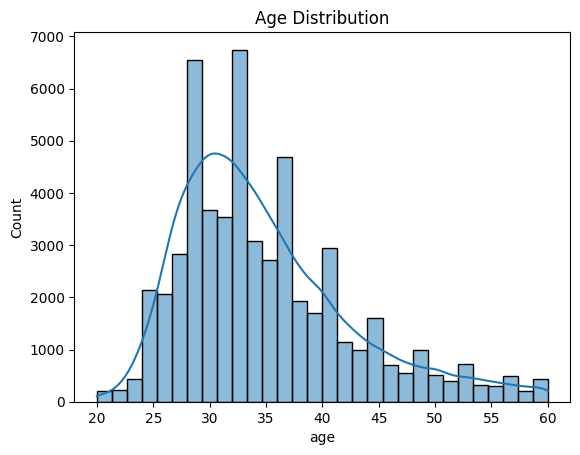

In [37]:
sns.histplot(df_train["age"], bins=30, kde=True)
plt.title("Age Distribution")
plt.show()

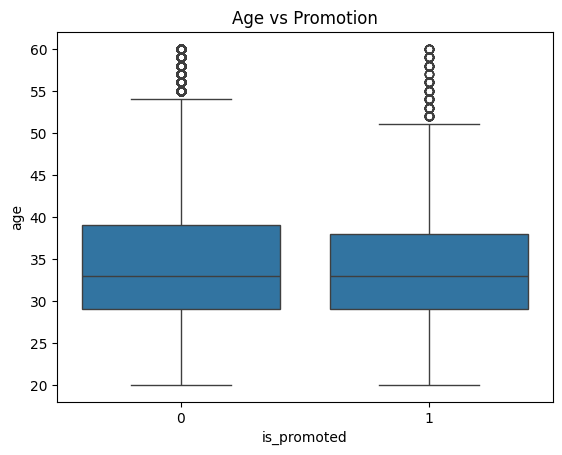

In [38]:
sns.boxplot(x="is_promoted", y="age", data=df_train)
plt.title("Age vs Promotion")
plt.show()

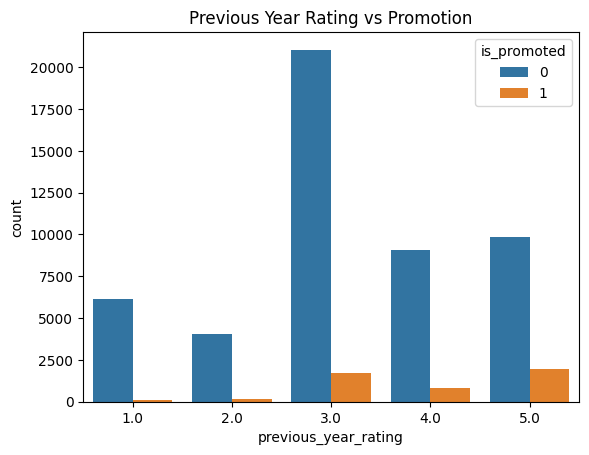

In [39]:
sns.countplot(x="previous_year_rating", hue="is_promoted", data=df_train)
plt.title("Previous Year Rating vs Promotion")
plt.show()

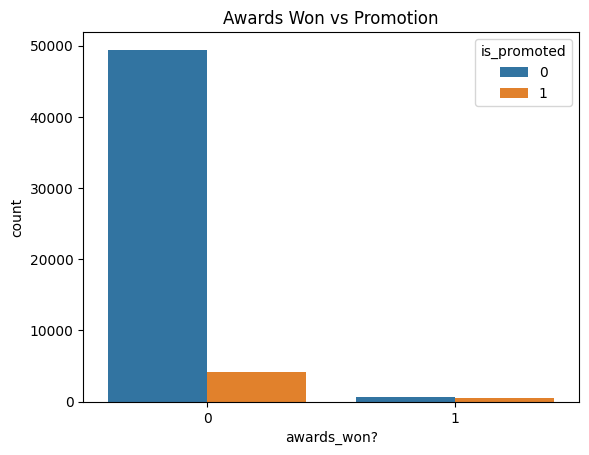

In [40]:
sns.countplot(x="awards_won?", hue="is_promoted", data=df_train)
plt.title("Awards Won vs Promotion")
plt.show()

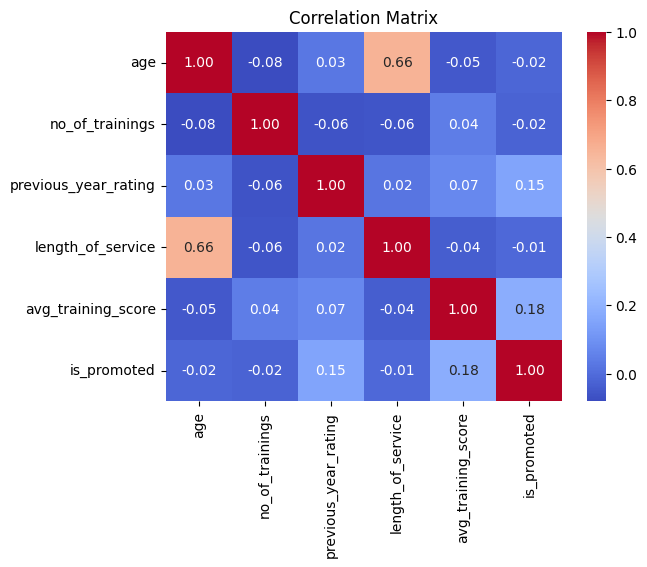

In [41]:
num_cols = [
    "age",
    "no_of_trainings",
    "previous_year_rating",
    "length_of_service",
    "avg_training_score",
    "is_promoted"
]

corr = df_train[num_cols].corr()

sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Matrix")
plt.show()

In [42]:
# remove employee_id from both dataframes
#df_train.drop(['employee_id'], axis=1, inplace=True)
#df_test.drop(['employee_id'], axis=1, inplace=True)

In [43]:
# check unique values for all columns in df_train
for col in df_train.columns:
    print(col)
    print(f"Values: \n{df_train[col].unique()}")
    print(f"Number of Values: {len(df_train[col].unique())}")
    print(f"Datatype: {df_train[col].dtype}")
    print("=========================================")

employee_id
Values: 
[65438 65141  7513 ... 13918 13614 51526]
Number of Values: 54808
Datatype: int64
department
Values: 
['Sales & Marketing' 'Operations' 'Technology' 'Analytics' 'R&D'
 'Procurement' 'Finance' 'HR' 'Legal']
Number of Values: 9
Datatype: object
region
Values: 
['region_7' 'region_22' 'region_19' 'region_23' 'region_26' 'region_2'
 'region_20' 'region_34' 'region_1' 'region_4' 'region_29' 'region_31'
 'region_15' 'region_14' 'region_11' 'region_5' 'region_28' 'region_17'
 'region_13' 'region_16' 'region_25' 'region_10' 'region_27' 'region_30'
 'region_12' 'region_21' 'region_8' 'region_32' 'region_6' 'region_33'
 'region_24' 'region_3' 'region_9' 'region_18']
Number of Values: 34
Datatype: object
education
Values: 
["Master's & above" "Bachelor's" 'Below Secondary']
Number of Values: 3
Datatype: object
gender
Values: 
['f' 'm']
Number of Values: 2
Datatype: object
recruitment_channel
Values: 
['sourcing' 'other' 'referred']
Number of Values: 3
Datatype: object
no_of_t

In [44]:
# check unique values for all columns in df_test
for col in df_test.columns:
    print(col)
    print(f"Values: \n{df_test[col].unique()}")
    print(f"Number of Values: {len(df_test[col].unique())}")
    print(f"Datatype: {df_test[col].dtype}")
    print("=========================================")

employee_id
Values: 
[ 8724 74430 72255 ... 45409  1186  5973]
Number of Values: 23490
Datatype: int64
department
Values: 
['Technology' 'HR' 'Sales & Marketing' 'Procurement' 'Finance' 'Analytics'
 'Operations' 'Legal' 'R&D']
Number of Values: 9
Datatype: object
region
Values: 
['region_26' 'region_4' 'region_13' 'region_2' 'region_29' 'region_7'
 'region_22' 'region_16' 'region_17' 'region_24' 'region_11' 'region_27'
 'region_9' 'region_20' 'region_34' 'region_23' 'region_8' 'region_14'
 'region_31' 'region_19' 'region_5' 'region_28' 'region_15' 'region_3'
 'region_25' 'region_12' 'region_21' 'region_30' 'region_10' 'region_33'
 'region_32' 'region_6' 'region_1' 'region_18']
Number of Values: 34
Datatype: object
education
Values: 
["Bachelor's" "Master's & above" 'Below Secondary']
Number of Values: 3
Datatype: object
gender
Values: 
['m' 'f']
Number of Values: 2
Datatype: object
recruitment_channel
Values: 
['sourcing' 'other' 'referred']
Number of Values: 3
Datatype: object
no_of_t

In [45]:
df_train['previous_year_rating'] = df_train['previous_year_rating'].astype(np.int64)
df_test['previous_year_rating'] = df_test['previous_year_rating'].astype(np.int64)

In [46]:
# checking preprocessed df_train
df_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 54808 entries, 0 to 54807
Data columns (total 13 columns):
 #   Column                Non-Null Count  Dtype 
---  ------                --------------  ----- 
 0   employee_id           54808 non-null  int64 
 1   department            54808 non-null  object
 2   region                54808 non-null  object
 3   education             54808 non-null  object
 4   gender                54808 non-null  object
 5   recruitment_channel   54808 non-null  object
 6   no_of_trainings       54808 non-null  int64 
 7   age                   54808 non-null  int64 
 8   previous_year_rating  54808 non-null  int64 
 9   length_of_service     54808 non-null  int64 
 10  awards_won?           54808 non-null  int64 
 11  avg_training_score    54808 non-null  int64 
 12  is_promoted           54808 non-null  int64 
dtypes: int64(8), object(5)
memory usage: 5.4+ MB


In [47]:
# checking preprocessed df_test
df_test.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 23490 entries, 0 to 23489
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype 
---  ------                --------------  ----- 
 0   employee_id           23490 non-null  int64 
 1   department            23490 non-null  object
 2   region                23490 non-null  object
 3   education             23490 non-null  object
 4   gender                23490 non-null  object
 5   recruitment_channel   23490 non-null  object
 6   no_of_trainings       23490 non-null  int64 
 7   age                   23490 non-null  int64 
 8   previous_year_rating  23490 non-null  int64 
 9   length_of_service     23490 non-null  int64 
 10  awards_won?           23490 non-null  int64 
 11  avg_training_score    23490 non-null  int64 
dtypes: int64(7), object(5)
memory usage: 2.2+ MB


In [48]:
df_train.head()

,employee_id,department,region,education,gender,recruitment_channel,no_of_trainings,age,previous_year_rating,length_of_service,awards_won?,avg_training_score,is_promoted
0,65438,Sales & Marketing,region_7,Master's & above,f,sourcing,1,35,5,8,0,49,0
1,65141,Operations,region_22,Bachelor's,m,other,1,30,5,4,0,60,0
2,7513,Sales & Marketing,region_19,Bachelor's,m,sourcing,1,34,3,7,0,50,0
3,2542,Sales & Marketing,region_23,Bachelor's,m,other,2,39,1,10,0,50,0
4,48945,Technology,region_26,Bachelor's,m,other,1,45,3,2,0,73,0


In [49]:
df_test.head()

,employee_id,department,region,education,gender,recruitment_channel,no_of_trainings,age,previous_year_rating,length_of_service,awards_won?,avg_training_score
0,8724,Technology,region_26,Bachelor's,m,sourcing,1,24,3,1,0,77
1,74430,HR,region_4,Bachelor's,f,other,1,31,3,5,0,51
2,72255,Sales & Marketing,region_13,Bachelor's,m,other,1,31,1,4,0,47
3,38562,Procurement,region_2,Bachelor's,f,other,3,31,2,9,0,65
4,64486,Finance,region_29,Bachelor's,m,sourcing,1,30,4,7,0,61


In [50]:
df_train.to_csv(
    "train_base_preprocessed.csv",
    index=False
)

In [51]:
df_test.to_csv(
    "test_base_preprocessed.csv",
    index=False
)